In [1]:
import sys
print(sys.version)
print(spark.version)

3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:38:13) [GCC 12.3.0]
3.5.1


In [1]:
# Load data
from pyspark.sql import SparkSession
gcs_path = "gs://msca-bdp-students-bucket/notebooks/jiayue1/reviews_meta_final_parquet/"
df_clean = spark.read.parquet(gcs_path)
df_clean.printSchema()

root
 |-- parent_asin: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- product_title: string (nullable = true)
 |-- store: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- product_avg_rating: double (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- price: string (nullable = true)



In [2]:
df_clean.createOrReplaceTempView("reviews")

## 1. Category Selection and Data Sampling

Selecting **Amazon Fashion** category and applying sampling for computational efficiency.

In [4]:
from pyspark.sql.functions import col, lower, trim, date_format, from_unixtime, year, count
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

# Filter for book category
df_books = df_clean.filter(col("main_category") == "AMAZON FASHION")

# Check total count
total_books_count = df_books.count()
print(f"Total Books reviews: {total_books_count:,}")

# Sample 5% for computational efficiency
sample_fraction = 0.01
df_sample = df_books.sample(withReplacement=False, fraction=sample_fraction, seed=42)
sample_count = df_sample.count()
print(f"Sampled reviews (10%): {sample_count:,}")

Total Books reviews: 804,167


Sampled reviews (10%): 8,116


## 2. Basic Uniqueness Check

In [5]:
# Check for exact duplicates
title_stats = df_sample.select("title").agg(
    count("*").alias("total"),
    count(col("title")).alias("non_null"),
    count(col("title").isNotNull().cast("int")).alias("distinct")
).collect()[0]

text_stats = df_sample.select("text").agg(
    count("*").alias("total"),
    count(col("text")).alias("non_null"),
    count(col("text").isNotNull().cast("int")).alias("distinct")
).collect()[0]

# Calculate exact duplicate counts
distinct_titles = df_sample.select("title").distinct().count()
distinct_texts = df_sample.select("text").distinct().count()

exact_title_duplicates = sample_count - distinct_titles
exact_text_duplicates = sample_count - distinct_texts

print("\n=== Exact Duplicate Analysis ===")
print(f"Total reviews: {sample_count:,}")
print(f"\nTitles:")
print(f"  Distinct: {distinct_titles:,}")
print(f"  Exact duplicates: {exact_title_duplicates:,} ({exact_title_duplicates/sample_count*100:.2f}%)")
print(f"\nTexts:")
print(f"  Distinct: {distinct_texts:,}")
print(f"  Exact duplicates: {exact_text_duplicates:,} ({exact_text_duplicates/sample_count*100:.2f}%)")


=== Exact Duplicate Analysis ===
Total reviews: 8,116

Titles:
  Distinct: 5,934
  Exact duplicates: 2,182 (26.89%)

Texts:
  Distinct: 7,839
  Exact duplicates: 277 (3.41%)


## 3. LSH-Based Similarity Detection

Using MinHashLSH to detect near-duplicate reviews.

In [6]:
from pyspark.ml.feature import MinHashLSH, RegexTokenizer, HashingTF
from pyspark.sql.functions import monotonically_increasing_id, col, trim, length, udf, size as array_size
from pyspark.sql.types import BooleanType

def prepare_lsh_model(df, text_col, num_hash_tables=5):
    """
    Prepare LSH model for similarity detection with robust empty vector handling.
    
    Args:
        df: Input DataFrame
        text_col: Column name containing text
        num_hash_tables: Number of hash tables for LSH
    
    Returns:
        Fitted LSH model and transformed DataFrame (already filtered for valid vectors)
    """
    print(f"  Processing column: {text_col}")
    
    # Step 1: Filter non-null, non-empty values with minimum length
    df_filtered = df.filter(
        (col(text_col).isNotNull()) & 
        (trim(col(text_col)) != "") &
        (length(col(text_col)) >= 3)  # At least 3 characters
    )
    
    initial_count = df_filtered.count()
    print(f"  Initial valid rows: {initial_count:,}")
    
    # Step 2: Add unique ID
    df_with_id = df_filtered.withColumn("id", monotonically_increasing_id())
    
    # Step 3: Tokenization
    tokenizer = RegexTokenizer(
        inputCol=text_col,
        outputCol="tokens",
        pattern="\\W",
        minTokenLength=1  # Accept tokens of at least 1 character
    )
    df_tokenized = tokenizer.transform(df_with_id)
    
    # Step 4: Filter out rows with empty token arrays
    df_tokenized = df_tokenized.filter(
        (col("tokens").isNotNull()) & 
        (array_size(col("tokens")) > 0)
    )
    
    token_count = df_tokenized.count()
    print(f"  After tokenization: {token_count:,}")
    
    # Step 5: Convert to feature vectors
    hashing_tf = HashingTF(
        inputCol="tokens",
        outputCol="features",
        numFeatures=1024
    )
    df_features = hashing_tf.transform(df_tokenized)
    
    # Step 6: CRITICAL - Filter empty feature vectors BEFORE LSH
    # Create a UDF to check for non-zero features
    @udf(BooleanType())
    def has_nonzero_features_udf(features):
        """Check if sparse vector has at least one non-zero element"""
        try:
            if features is None:
                return False
            # For sparse vectors, check numNonzeros
            if hasattr(features, 'numNonzeros'):
                return features.numNonzeros() > 0
            # For dense vectors, check if any value is non-zero
            if hasattr(features, 'values'):
                return len(features.values) > 0 and any(v != 0 for v in features.values)
            return False
        except:
            return False
    
    df_features_valid = df_features.filter(has_nonzero_features_udf(col("features")))
    
    valid_count = df_features_valid.count()
    print(f"  Valid feature vectors: {valid_count:,}")
    
    if valid_count == 0:
        raise ValueError(f"No valid feature vectors found for column '{text_col}'")
    
    # Step 7: Fit LSH model on FILTERED data
    lsh = MinHashLSH(
        inputCol="features",
        outputCol="hashes",
        numHashTables=num_hash_tables
    )
    lsh_model = lsh.fit(df_features_valid)
    
    # Step 8: Transform with LSH (should not fail now)
    df_hashed = lsh_model.transform(df_features_valid)
    
    final_count = df_hashed.count()
    print(f"  Final hashed vectors: {final_count:,}")
    
    return lsh_model, df_hashed

In [7]:
def find_similar_pairs(lsh_model, df_hashed, threshold=0.3):
    """
    Find similar pairs using LSH with error handling.
    
    Args:
        lsh_model: Fitted LSH model
        df_hashed: DataFrame with LSH hashes (must have valid features only)
        threshold: Jaccard distance threshold
    
    Returns:
        DataFrame of similar pairs
    """
    print(f"  Finding similar pairs with threshold {threshold}...")
    
    # The input df_hashed should already be filtered for valid vectors
    # But add a safety check
    row_count = df_hashed.count()
    print(f"  Input rows: {row_count:,}")
    
    if row_count == 0:
        print("  WARNING: No rows to compare")
        # Return empty DataFrame with expected schema
        from pyspark.sql.types import StructType, StructField, DoubleType
        empty_schema = StructType([
            StructField("datasetA", df_hashed.schema),
            StructField("datasetB", df_hashed.schema),
            StructField("jaccard_distance", DoubleType())
        ])
        return spark.createDataFrame([], empty_schema)
    
    # Perform similarity join
    similar_pairs = lsh_model.approxSimilarityJoin(
        df_hashed, 
        df_hashed, 
        threshold,
        distCol="jaccard_distance"
    )
    
    # Filter out self-matches and keep only i < j to avoid duplicates
    similar_pairs_filtered = similar_pairs.filter(
        col("datasetA.id") < col("datasetB.id")
    )
    
    pair_count = similar_pairs_filtered.count()
    print(f"  Similar pairs found: {pair_count:,}")
    
    return similar_pairs_filtered

In [9]:
def count_duplicates_correctly(similar_pairs):
    """
    CORRECTED: Count unique items that have at least one duplicate.
    
    The previous approach counted pairs, which underestimates duplicates.
    This function counts unique reviews that appear in any similar pair.
    
    Args:
        similar_pairs: DataFrame of similar pairs
    
    Returns:
        Number of unique items with duplicates
    """
    from pyspark.sql.functions import col
    
    # Collect all IDs that appear in similar pairs
    ids_a = similar_pairs.select(col("datasetA.id").alias("id"))
    ids_b = similar_pairs.select(col("datasetB.id").alias("id"))
    
    # Union and get distinct count
    unique_duplicate_ids = ids_a.union(ids_b).distinct().count()
    
    return unique_duplicate_ids

print("Setting up LSH pipeline...")

Setting up LSH pipeline...


## 4. Overall Duplication Analysis

In [10]:
print("\n" + "="*60)
print("ANALYZING REVIEW TITLES")
print("="*60)

try:
    # Prepare LSH for titles (now with built-in filtering)
    lsh_model_title, df_title_hashed = prepare_lsh_model(df_sample, "title", num_hash_tables=5)
    total_titles = df_title_hashed.count()
    print(f"Total valid titles: {total_titles:,}")
    
    # Find similar title pairs
    similar_title_pairs = find_similar_pairs(lsh_model_title, df_title_hashed, threshold=0.3)
    n_similar_title_pairs = similar_title_pairs.count()
    
    n_titles_with_duplicates = count_duplicates_correctly(similar_title_pairs)
    
    title_duplication_rate = (n_titles_with_duplicates / total_titles * 100) if total_titles > 0 else 0
    
    print(f"\nSimilar pairs found: {n_similar_title_pairs:,}")
    print(f"Unique titles with duplicates: {n_titles_with_duplicates:,}")
    print(f"Duplication rate: {title_duplication_rate:.2f}%")
    print(f"Unique titles: {total_titles - n_titles_with_duplicates:,} ({(total_titles - n_titles_with_duplicates)/total_titles*100:.2f}%)")
    
except Exception as e:
    print(f"ERROR in title analysis: {e}")
    import traceback
    traceback.print_exc()



ANALYZING REVIEW TITLES
  Processing column: title


  Initial valid rows: 8,064


  After tokenization: 8,058


  Valid feature vectors: 8,058


  Final hashed vectors: 8,058


Total valid titles: 8,058
  Finding similar pairs with threshold 0.3...


  Input rows: 8,058


  Similar pairs found: 125,681



Similar pairs found: 125,681
Unique titles with duplicates: 3,662
Duplication rate: 45.45%
Unique titles: 4,396 (54.55%)


In [11]:

try:
    # Prepare LSH for review texts (now with built-in filtering)
    lsh_model_text, df_text_hashed = prepare_lsh_model(df_sample, "text", num_hash_tables=5)
    total_texts = df_text_hashed.count()
    print(f"Total valid texts: {total_texts:,}")
    
    # Find similar text pairs
    similar_text_pairs = find_similar_pairs(lsh_model_text, df_text_hashed, threshold=0.3)
    n_similar_text_pairs = similar_text_pairs.count()
    
    # CORRECTED: Count unique texts with duplicates
    n_texts_with_duplicates = count_duplicates_correctly(similar_text_pairs)
    
    text_duplication_rate = (n_texts_with_duplicates / total_texts * 100) if total_texts > 0 else 0
    
    print(f"\nSimilar pairs found: {n_similar_text_pairs:,}")
    print(f"Unique texts with duplicates: {n_texts_with_duplicates:,}")
    print(f"Duplication rate: {text_duplication_rate:.2f}%")
    print(f"Unique texts: {total_texts - n_texts_with_duplicates:,} ({(total_texts - n_texts_with_duplicates)/total_texts*100:.2f}%)")
    
except Exception as e:
    print(f"ERROR in text analysis: {e}")
    import traceback
    traceback.print_exc()

  Processing column: text


  Initial valid rows: 8,076


  After tokenization: 8,072


  Valid feature vectors: 8,072


  Final hashed vectors: 8,072


Total valid texts: 8,072
  Finding similar pairs with threshold 0.3...


  Input rows: 8,072


  Similar pairs found: 3,302



Similar pairs found: 3,302
Unique texts with duplicates: 597
Duplication rate: 7.40%
Unique texts: 7,475 (92.60%)


### Visualization: Overall Duplication Rates

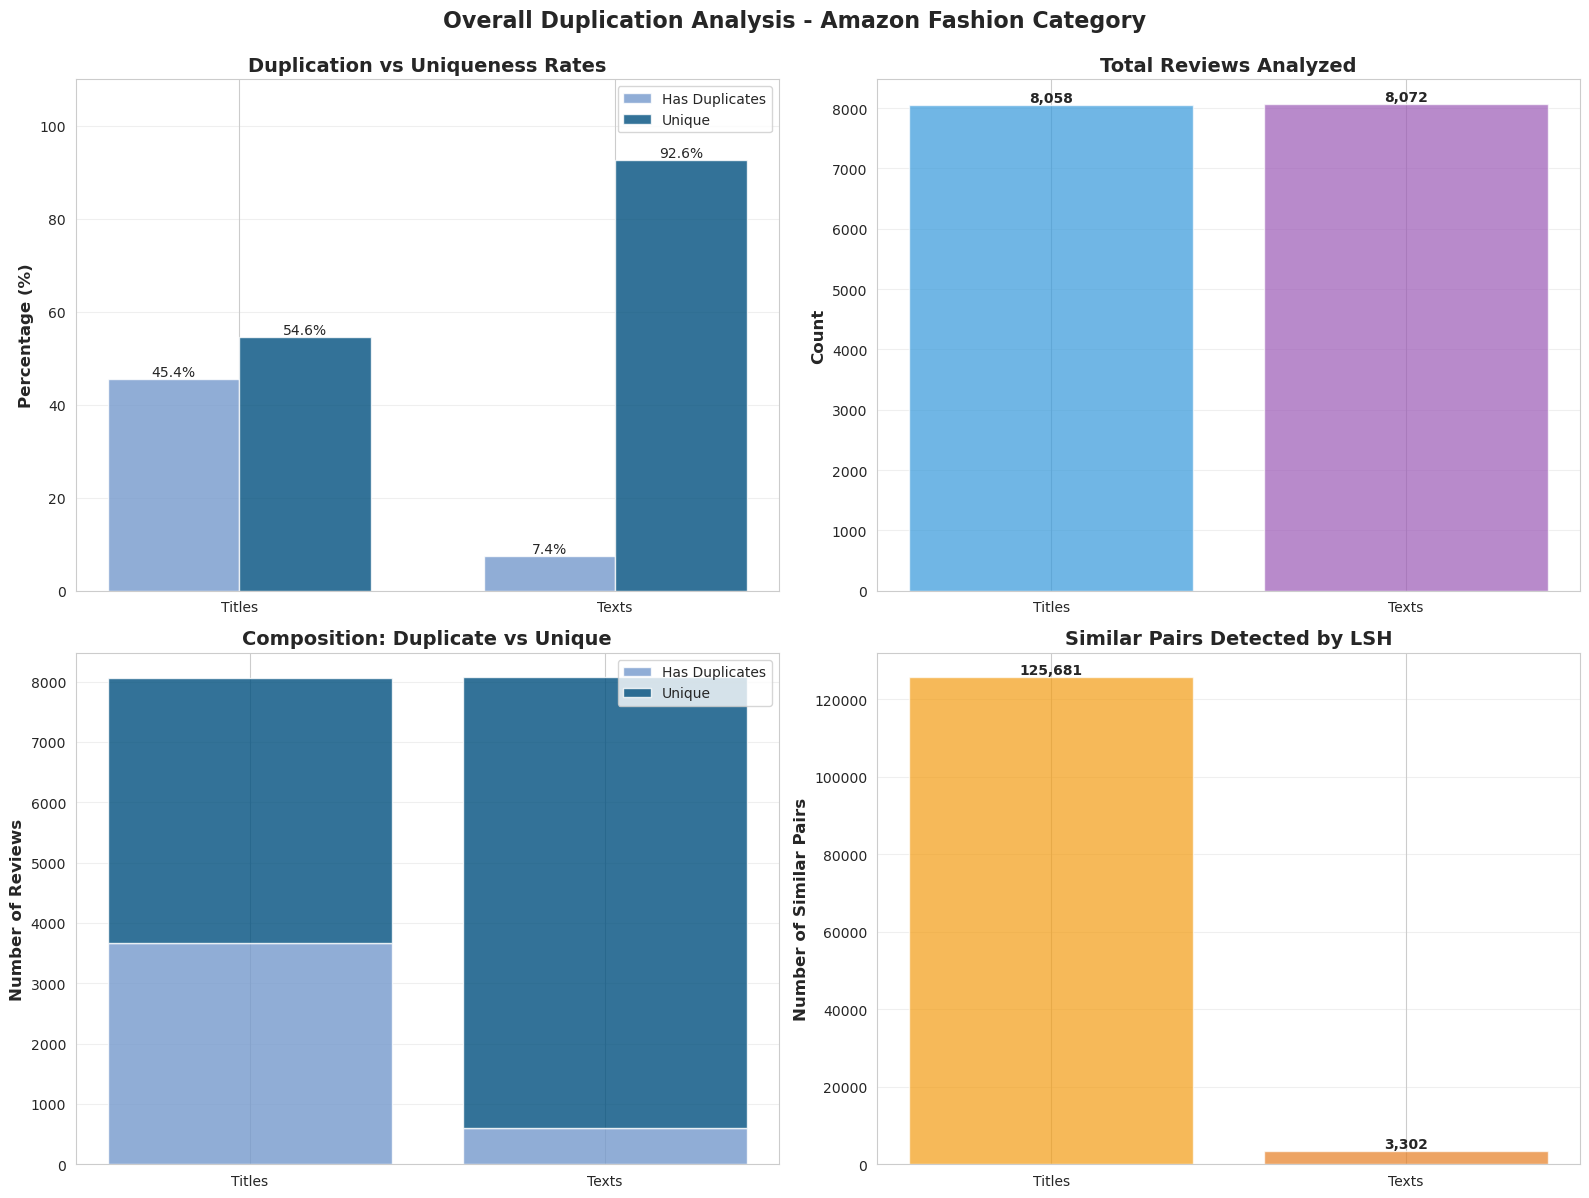


KEY FINDINGS
Title duplication: 45.45% of reviews have similar titles
Text duplication: 7.40% of reviews have similar content

This means:
  - 3,662 titles appear in duplicate/similar pairs
  - 597 review texts appear in duplicate/similar pairs


In [13]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Duplication Rate Comparison
categories = ['Titles', 'Texts']
duplication_rates = [title_duplication_rate, text_duplication_rate]
unique_rates = [100 - title_duplication_rate, 100 - text_duplication_rate]

x = np.arange(len(categories))
width = 0.35

bars1 = axes[0, 0].bar(x - width/2, duplication_rates, width, 
                        label='Has Duplicates', color='#7599cc', alpha=0.8)
bars2 = axes[0, 0].bar(x + width/2, unique_rates, width, 
                        label='Unique', color='#004f7e', alpha=0.8)

axes[0, 0].set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Duplication vs Uniqueness Rates', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(categories)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim(0, 110)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# 2. Sample Size Comparison
counts = [total_titles, total_texts]
axes[0, 1].bar(categories, counts, color=['#3498db', '#9b59b6'], alpha=0.7)
axes[0, 1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Total Reviews Analyzed', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(counts):
    axes[0, 1].text(i, v, f'{v:,}', ha='center', va='bottom', 
                   fontsize=10, fontweight='bold')

# 3. Stacked composition
duplicate_counts = [n_titles_with_duplicates, n_texts_with_duplicates]
unique_counts = [total_titles - n_titles_with_duplicates, 
                 total_texts - n_texts_with_duplicates]

axes[1, 0].bar(categories, duplicate_counts, label='Has Duplicates', 
               color='#7599cc', alpha=0.8)
axes[1, 0].bar(categories, unique_counts, bottom=duplicate_counts, 
               label='Unique', color='#004f7e', alpha=0.8)

axes[1, 0].set_ylabel('Number of Reviews', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Composition: Duplicate vs Unique', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Similar Pairs Found
pair_counts = [n_similar_title_pairs, n_similar_text_pairs]
axes[1, 1].bar(categories, pair_counts, color=['#f39c12', '#e67e22'], alpha=0.7)
axes[1, 1].set_ylabel('Number of Similar Pairs', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Similar Pairs Detected by LSH', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(pair_counts):
    axes[1, 1].text(i, v, f'{v:,}', ha='center', va='bottom', 
                   fontsize=10, fontweight='bold')

plt.suptitle('Overall Duplication Analysis - Amazon Fashion Category', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)
print(f"Title duplication: {title_duplication_rate:.2f}% of reviews have similar titles")
print(f"Text duplication: {text_duplication_rate:.2f}% of reviews have similar content")
print(f"\nThis means:")
print(f"  - {n_titles_with_duplicates:,} titles appear in duplicate/similar pairs")
print(f"  - {n_texts_with_duplicates:,} review texts appear in duplicate/similar pairs")

## 5. Top 5 Products Analysis

In [14]:
# Identify top 5 products by review count
top_products = df_sample.groupBy("parent_asin", "product_title") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(5) \
    .collect()

print("\n" + "="*60)
print("TOP 5 PRODUCTS BY REVIEW COUNT")
print("="*60)
for i, row in enumerate(top_products, 1):
    product_title = row['product_title'][:60] + "..." if len(row['product_title']) > 60 else row['product_title']
    print(f"{i}. {product_title}")
    print(f"   ASIN: {row['parent_asin']} | Reviews: {row['count']:,}")

top_asins = [row['parent_asin'] for row in top_products]


TOP 5 PRODUCTS BY REVIEW COUNT
1. Ailun Screen Protector Compatible for iPhone 8 plus,7 Plus,6...
   ASIN: B01LXZDPDR | Reviews: 246
2. [2+2 Pack] LK Compatible for Samsung Galaxy S10 6.1inch, 2 P...
   ASIN: B07Q2B84ZK | Reviews: 47
3. Joomra Pillow Slippers for Women and Men Non Slip Quick Dryi...
   ASIN: B0965389V6 | Reviews: 46
4. FROGG TOGGS Men's Ultra-Lite2 Waterproof Breathable Rain Sui...
   ASIN: B0BZFTL523 | Reviews: 41
5. Toes Home 6PCS Outdoor Headband Elastic Seamless Bandana Nec...
   ASIN: B08BQ2CKFM | Reviews: 33


In [15]:
# Analyze each product
product_results = []

for idx, asin in enumerate(top_asins, 1):
    product_title = top_products[idx-1]['product_title']
    print(f"\n{'='*60}")
    print(f"Analyzing Product {idx}: {product_title[:50]}...")
    print(f"{'='*60}")
    
    # Filter for this product
    df_product = df_sample.filter(col("parent_asin") == asin)
    
    # Titles
    lsh_prod_title, df_prod_title_hashed = prepare_lsh_model(
        df_product, "title", num_hash_tables=3
    )
    total_prod_titles = df_prod_title_hashed.count()
    
    similar_prod_title_pairs = find_similar_pairs(
        lsh_prod_title, df_prod_title_hashed, threshold=0.3
    )
    n_prod_similar_title_pairs = similar_prod_title_pairs.count()
    n_prod_titles_with_duplicates = count_duplicates_correctly(similar_prod_title_pairs)
    prod_title_dup_rate = (n_prod_titles_with_duplicates / total_prod_titles * 100) if total_prod_titles > 0 else 0
    
    # Texts
    lsh_prod_text, df_prod_text_hashed = prepare_lsh_model(
        df_product, "text", num_hash_tables=3
    )
    total_prod_texts = df_prod_text_hashed.count()
    
    similar_prod_text_pairs = find_similar_pairs(
        lsh_prod_text, df_prod_text_hashed, threshold=0.3
    )
    n_prod_similar_text_pairs = similar_prod_text_pairs.count()
    n_prod_texts_with_duplicates = count_duplicates_correctly(similar_prod_text_pairs)
    prod_text_dup_rate = (n_prod_texts_with_duplicates / total_prod_texts * 100) if total_prod_texts > 0 else 0
    
    print(f"\nTitles: {total_prod_titles:,} total, {n_prod_titles_with_duplicates:,} with duplicates ({prod_title_dup_rate:.2f}%)")
    print(f"Texts:  {total_prod_texts:,} total, {n_prod_texts_with_duplicates:,} with duplicates ({prod_text_dup_rate:.2f}%)")
    
    product_results.append({
        'product_num': idx,
        'asin': asin,
        'product_title': product_title,
        'total_titles': total_prod_titles,
        'title_duplicates': n_prod_titles_with_duplicates,
        'title_dup_rate': prod_title_dup_rate,
        'total_texts': total_prod_texts,
        'text_duplicates': n_prod_texts_with_duplicates,
        'text_dup_rate': prod_text_dup_rate
    })

print("\nAnalysis complete for all products!")


Analyzing Product 1: Ailun Screen Protector Compatible for iPhone 8 plu...
  Processing column: title


  Initial valid rows: 243


  After tokenization: 241


  Valid feature vectors: 241


  Final hashed vectors: 241


...

  Final hashed vectors: 32


  Finding similar pairs with threshold 0.3...


  Input rows: 32


  Similar pairs found: 0



Titles: 32 total, 3 with duplicates (9.38%)
Texts:  32 total, 0 with duplicates (0.00%)

Analysis complete for all products!


### Visualization: Top 5 Products Duplication

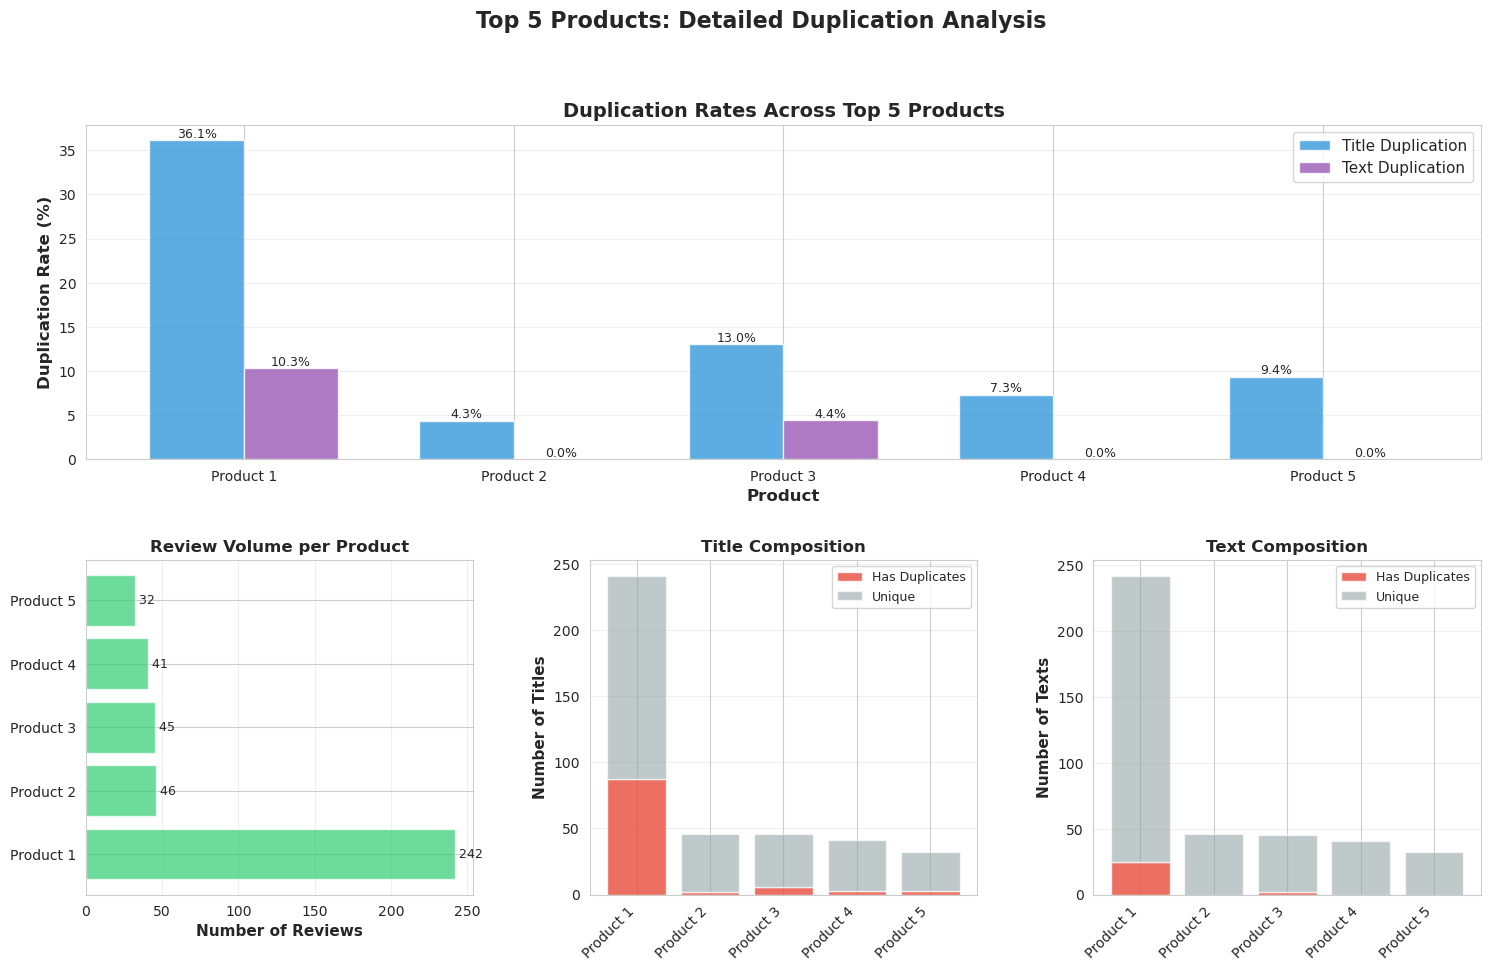


SUMMARY TABLE: TOP 5 PRODUCTS
Product    Reviews    Title Dup %     Text Dup %     
----------------------------------------------------------------------------------------------------
Product 1   242        36.10           10.33          
Product 2   46         4.35            0.00           
Product 3   45         13.04           4.44           
Product 4   41         7.32            0.00           
Product 5   32         9.38            0.00           


In [16]:
# Create comprehensive product visualization
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Extract data for visualization
product_labels = [f"Product {r['product_num']}" for r in product_results]
title_dup_rates = [r['title_dup_rate'] for r in product_results]
text_dup_rates = [r['text_dup_rate'] for r in product_results]
review_counts = [r['total_texts'] for r in product_results]

# 1. Grouped bar chart for duplication rates
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(product_labels))
width = 0.35

bars1 = ax1.bar(x - width/2, title_dup_rates, width, 
                label='Title Duplication', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x + width/2, text_dup_rates, width, 
                label='Text Duplication', color='#9b59b6', alpha=0.8)

ax1.set_xlabel('Product', fontsize=12, fontweight='bold')
ax1.set_ylabel('Duplication Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Duplication Rates Across Top 5 Products', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(product_labels)
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# 2. Review count distribution
ax2 = fig.add_subplot(gs[1, 0])
bars = ax2.barh(product_labels, review_counts, color='#2ecc71', alpha=0.7)
ax2.set_xlabel('Number of Reviews', fontsize=11, fontweight='bold')
ax2.set_title('Review Volume per Product', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for i, (bar, count) in enumerate(zip(bars, review_counts)):
    ax2.text(count, i, f' {count:,}', va='center', fontsize=9)

# 3. Title duplication details
ax3 = fig.add_subplot(gs[1, 1])
title_duplicates = [r['title_duplicates'] for r in product_results]
title_unique = [r['total_titles'] - r['title_duplicates'] for r in product_results]

ax3.bar(product_labels, title_duplicates, label='Has Duplicates', 
        color='#e74c3c', alpha=0.8)
ax3.bar(product_labels, title_unique, bottom=title_duplicates, 
        label='Unique', color='#95a5a6', alpha=0.6)

ax3.set_ylabel('Number of Titles', fontsize=11, fontweight='bold')
ax3.set_title('Title Composition', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4. Text duplication details
ax4 = fig.add_subplot(gs[1, 2])
text_duplicates = [r['text_duplicates'] for r in product_results]
text_unique = [r['total_texts'] - r['text_duplicates'] for r in product_results]

ax4.bar(product_labels, text_duplicates, label='Has Duplicates', 
        color='#e74c3c', alpha=0.8)
ax4.bar(product_labels, text_unique, bottom=text_duplicates, 
        label='Unique', color='#95a5a6', alpha=0.6)

ax4.set_ylabel('Number of Texts', fontsize=11, fontweight='bold')
ax4.set_title('Text Composition', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Top 5 Products: Detailed Duplication Analysis', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Print summary table
print("\n" + "="*100)
print("SUMMARY TABLE: TOP 5 PRODUCTS")
print("="*100)
print(f"{'Product':<10} {'Reviews':<10} {'Title Dup %':<15} {'Text Dup %':<15}")
print("-" * 100)
for r in product_results:
    print(f"Product {r['product_num']:<3} {r['total_texts']:<10,} {r['title_dup_rate']:<15.2f} {r['text_dup_rate']:<15.2f}")

In [18]:
print("\n" + "="*60)
print("ANALYZING RECENT REVIEWS (2022+) - TITLES")
print("="*60)

# Recent titles
lsh_recent_title, df_recent_title_hashed = prepare_lsh_model(
    df_recent, "title", num_hash_tables=5
)
n_recent_total_titles = df_recent_title_hashed.count()

similar_recent_title_pairs = find_similar_pairs(
    lsh_recent_title, df_recent_title_hashed, threshold=0.3
)
n_recent_similar_title_pairs = similar_recent_title_pairs.count()
n_recent_titles_with_duplicates = count_duplicates_correctly(similar_recent_title_pairs)
recent_title_dup_rate = (n_recent_titles_with_duplicates / n_recent_total_titles * 100) if n_recent_total_titles > 0 else 0

print(f"Total titles: {n_recent_total_titles:,}")
print(f"Similar pairs: {n_recent_similar_title_pairs:,}")
print(f"Titles with duplicates: {n_recent_titles_with_duplicates:,}")
print(f"Duplication rate: {recent_title_dup_rate:.2f}%")


ANALYZING RECENT REVIEWS (2022+) - TITLES
  Processing column: title


  Initial valid rows: 8,064


  After tokenization: 8,058


  Valid feature vectors: 8,058


  Final hashed vectors: 8,058


  Finding similar pairs with threshold 0.3...


  Input rows: 8,058


  Similar pairs found: 125,681


Total titles: 8,058
Similar pairs: 125,681
Titles with duplicates: 3,662
Duplication rate: 45.45%


In [19]:
print("\n" + "="*60)
print("ANALYZING RECENT REVIEWS (2022+) - TEXTS")
print("="*60)

# Recent texts
lsh_recent_text, df_recent_text_hashed = prepare_lsh_model(
    df_recent, "text", num_hash_tables=5
)
n_recent_total_texts = df_recent_text_hashed.count()

similar_recent_text_pairs = find_similar_pairs(
    lsh_recent_text, df_recent_text_hashed, threshold=0.3
)
n_recent_similar_text_pairs = similar_recent_text_pairs.count()
n_recent_texts_with_duplicates = count_duplicates_correctly(similar_recent_text_pairs)
recent_text_dup_rate = (n_recent_texts_with_duplicates / n_recent_total_texts * 100) if n_recent_total_texts > 0 else 0

print(f"Total texts: {n_recent_total_texts:,}")
print(f"Similar pairs: {n_recent_similar_text_pairs:,}")
print(f"Texts with duplicates: {n_recent_texts_with_duplicates:,}")
print(f"Duplication rate: {recent_text_dup_rate:.2f}%")


ANALYZING RECENT REVIEWS (2022+) - TEXTS
  Processing column: text


  Initial valid rows: 8,076


  After tokenization: 8,072


  Valid feature vectors: 8,072


  Final hashed vectors: 8,072


  Finding similar pairs with threshold 0.3...


  Input rows: 8,072


  Similar pairs found: 3,302


Total texts: 8,072
Similar pairs: 3,302
Texts with duplicates: 597
Duplication rate: 7.40%
